# Masaüstü OpenCV Jupyter Deneme Not Defteri 🌟
Bu notebook içerisinde istediğiniz görselleri griye çevirme denemeleri yapabilirsiniz.

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

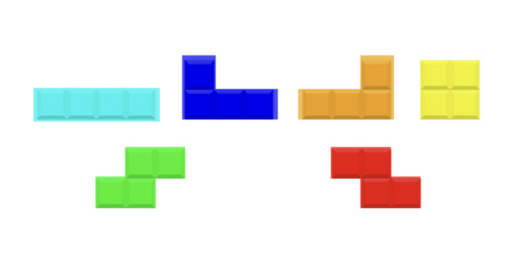

In [11]:
img = cv2.imread("resim.jpg") 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) 
plt.axis('off') 
plt.show()

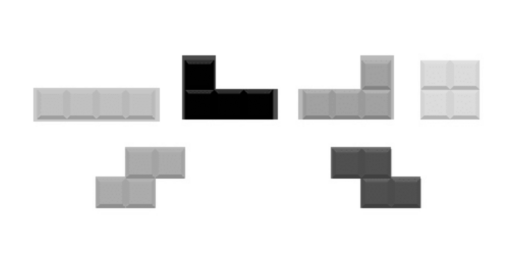

In [12]:
gray_img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img,cmap='gray')
plt.axis('off')
plt.show()

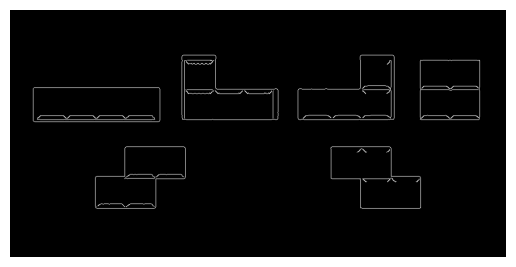

In [24]:
edges = cv2.Canny(gray_img,50,100)
plt.imshow(edges,cmap='gray')
plt.axis('off')
plt.show()

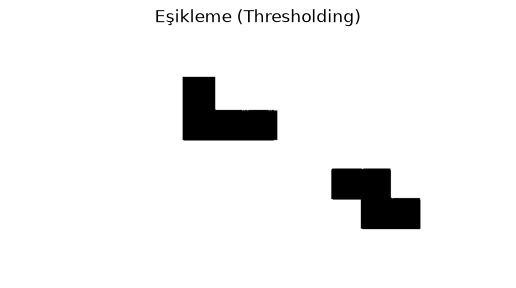

In [29]:
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
# Gri resmi 127 eşik değeriyle net siyah-beyaz (Binary) formata dönüştürür (127'den parlak pikseller 255 beyaz, karanlıklar 0 siyah yapılır).

plt.imshow(thresh, cmap="gray")
# Eşikleme yapılmış siyah-beyaz resmi gösterilmek üzere hazırlar.

plt.title("Eşikleme (Thresholding)")
# Görselin üstüne başlık ekler.

plt.axis("off")
# Kenarlardaki piksel sayı eksenlerini gizler.

plt.show()
# Eşiklenmiş görseli ekranda görüntüler.


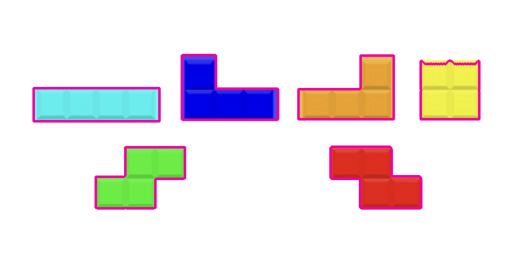

In [34]:
_, thresh = cv2.threshold(gray, 225, 255, cv2.THRESH_BINARY_INV)
# Arka planı siyah, 6 nesneyi beyaz yapar.

cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Sadece 6 nesnenin dış hatlarını bulur (dış çerçeveyi almaz).

output = img_rgb.copy()
# Orijinal resmin kopyasını alır.

cv2.drawContours(output, cnts, -1, (240, 0, 159), 3)
# 6 nesnenin etrafına dersteki gibi mor renkli çizgi çizer.

plt.imshow(output)
plt.axis("off")
plt.show()



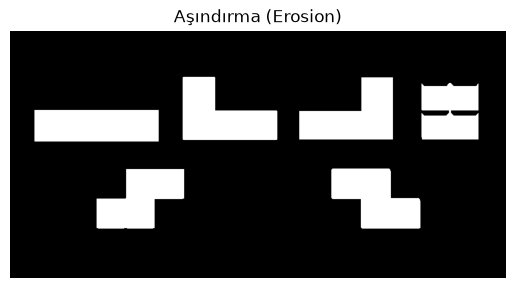

In [37]:
kernel = np.ones((5, 5), np.uint8)
# Aşındırma işlemi için 5x5 boyutunda 1'lerden oluşan matris (çekirdek) oluşturur.

erosion = cv2.erode(thresh, kernel, iterations=1)
# Eşiklenmiş (thresh) resimdeki beyaz nesne sınırlarını 1 adım aşındırır / inceltir.

plt.imshow(erosion, cmap="gray")
# Aşındırılmış resmi gösterilmek üzere hazırlar.

plt.title("Aşındırma (Erosion)")
plt.axis("off")
plt.show()




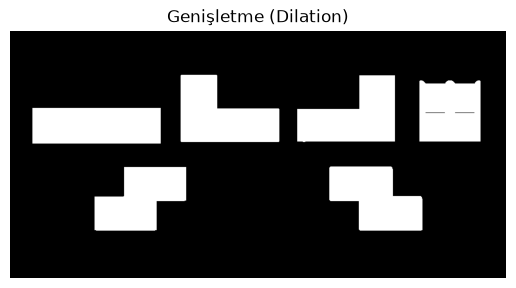

In [38]:
kernel = np.ones((5, 5), np.uint8)
# Genişletme işlemi için 5x5 boyutunda 1'lerden oluşan fırça matrisi oluşturur.

dilation = cv2.dilate(thresh, kernel, iterations=1)
# Eşiklenmiş (thresh) resimdeki beyaz nesnelerin sınırlarını 1 adım genişletir / etrafına et ekleyerek büyütür.

plt.imshow(dilation, cmap="gray")
# Genişletilmiş resmi gösterilmek üzere hazırlar.

plt.title("Genişletme (Dilation)")
plt.axis("off")
plt.show()



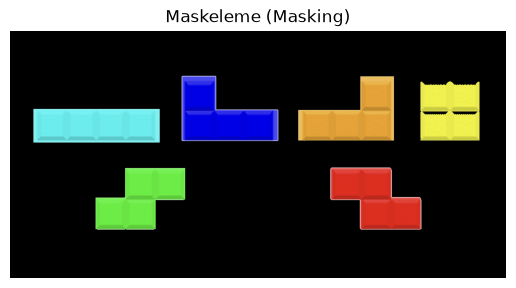

In [39]:
masked_img = cv2.bitwise_and(img_rgb, img_rgb, mask=thresh)
# Siyah-beyaz maskeyi (thresh) kullanarak sadece nesnelerin olduğu renkli pikselleri tutar, arka planı simsiyah (0) yapar.

plt.imshow(masked_img)
# Arka planı siyah yapılmış renkli görseli gösterilmek üzere hazırlar.

plt.title("Maskeleme (Masking)")
plt.axis("off")
plt.show()

